## Import Libraries

In [1]:
# Import library yang dibutuhkan
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Load Data

In [2]:
# Memuat dataset dari Kaggle
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "akmaldwiputra/student-lifestyle-dataset",
    "student_lifestyle_dataset.csv"
)

df.head()


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


### Insight: 
Dataset **Student Lifestyle** berisi informasi tentang gaya hidup mahasiswa dengan 8 kolom:
- **Student_ID**: Identitas unik mahasiswa
- **Study_Hours_Per_Day**: Jam belajar per hari
- **Extracurricular_Hours_Per_Day**: Jam kegiatan ekstrakurikuler
- **Sleep_Hours_Per_Day**: Jam tidur per hari
- **Social_Hours_Per_Day**: Jam bersosialisasi
- **Physical_Activity_Hours_Per_Day**: Jam aktivitas fisik
- **GPA**: Nilai rata-rata (Grade Point Average)
- **Stress_Level**: Tingkat stress (Low, Moderate, High)

## Exploratory Data Analysis (EDA)

In [3]:
# Menampilkan informasi dasar tentang dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


### Insight:
- **Total data**: 2000 mahasiswa
- **7 kolom numerik**: Study_Hours, Extracurricular_Hours, Sleep_Hours, Social_Hours, Physical_Activity_Hours, GPA, Student_ID
- **1 kolom kategorikal**: Stress_Level

In [4]:
# Menampilkan jumlah nilai yang hilang di setiap kolom
print(df.isnull().sum())


Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64


### Insight:
Tidak ada data yang hilang di semua kolom, dataset memiliki kualitas data yang baik dan tidak memerlukan imputasi.

In [5]:

# Menampilkan jumlah data duplikat
print("Jumlah duplikat:", df.duplicated().sum())


Jumlah duplikat: 0


### Insight:
Tidak ada data duplikat dan tidak ada pengulangan data.

In [6]:
# Menampilkan ringkasan statistik untuk kolom numerik
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Student_ID,2000.0,1000.50000,577.494589,1.00,500.75,1000.50,1500.25,2000.0
Study_Hours_Per_Day,2000.0,7.47580,1.423888,5.00,6.30,7.40,8.70,10.0
Extracurricular_Hours_Per_Day,2000.0,1.99010,1.155855,0.00,1.00,2.00,3.00,4.0
Sleep_Hours_Per_Day,2000.0,7.50125,1.460949,5.00,6.20,7.50,8.80,10.0
Social_Hours_Per_Day,2000.0,2.70455,1.688514,0.00,1.20,2.60,4.10,6.0
Physical_Activity_Hours_Per_Day,2000.0,4.32830,2.514110,0.00,2.40,4.10,6.10,13.0
GPA,2000.0,3.11596,0.298674,2.24,2.90,3.11,3.33,4.0


In [7]:
# Menampilkan ringkasan statistik untuk kolom kategorikal
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
display(df[categorical_cols].describe().T)

,count,unique,top,freq
Stress_Level,2000,3,High,1029


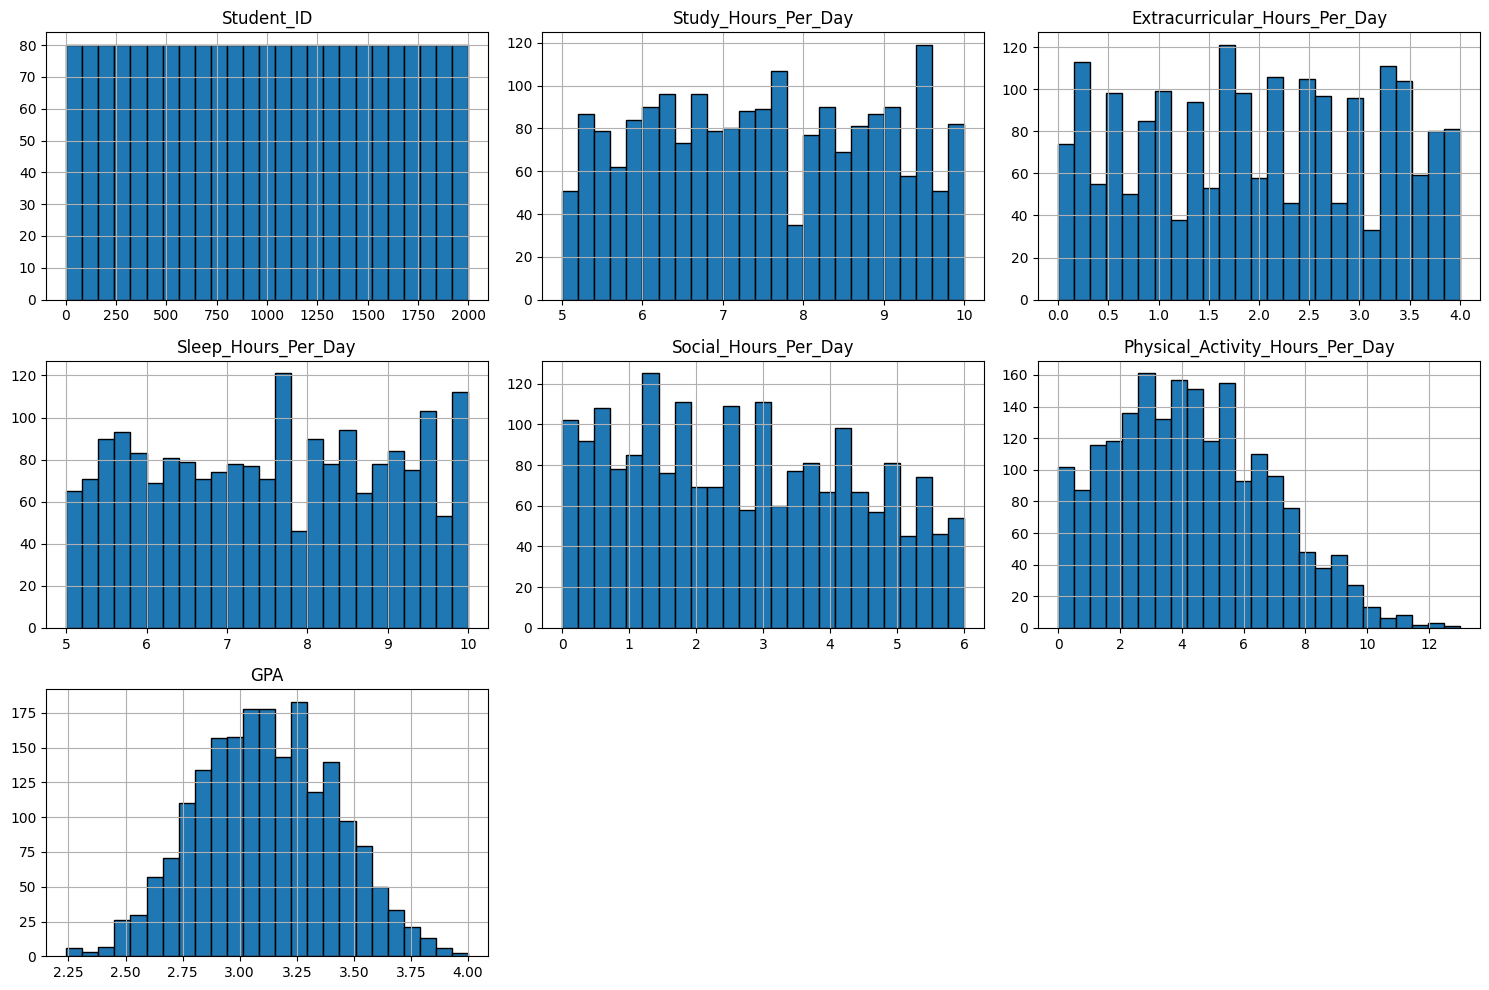

In [8]:
# Visualisasi distribusi fitur numerik
numerical_cols = df.select_dtypes(include=['number']).columns
df[numerical_cols].hist(figsize=(15, 10), bins=25, edgecolor='black')
plt.tight_layout()
plt.show()

### Insight: 

- Tidak ada fitur yang memiliki distribusi sangat skewed
- Sebagian besar fitur memiliki variasi yang baik untuk analisis clustering

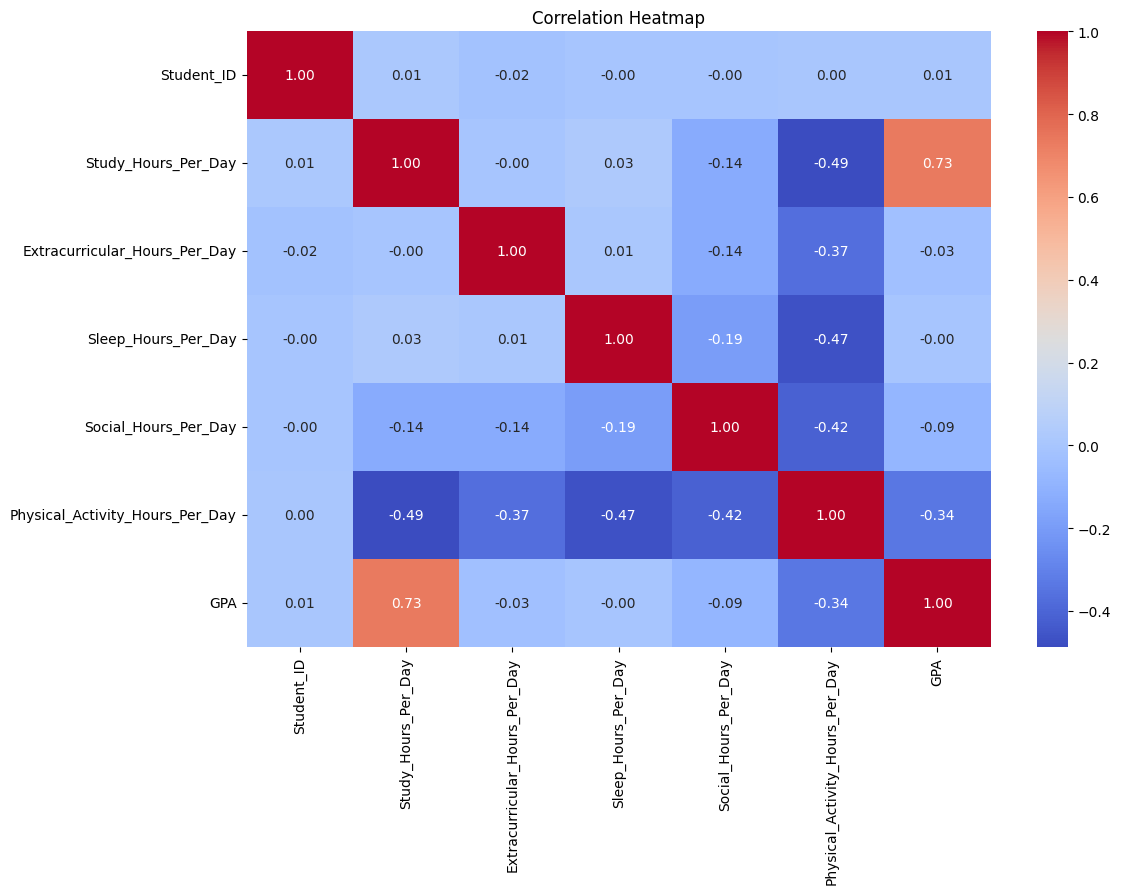

In [9]:
# Menampilkan korelasi antar fitur numerik
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight: 
- Perlu keseimbangan antara belajar, tidur, dan aktivitas fisik
- Mahasiswa perlu manajemen waktu yang lebih baik

**Korelasi Positif :**
- **Study_Hours ↔ GPA**: Semakin banyak belajar, GPA cenderung lebih tinggi

**Korelasi Negatif:**
- **Sleep_Hours ↔ Study_Hours**: Trade-off antara jam belajar dan tidur
- **Physical_Activity ↔ Study_Hours**: Mahasiswa yang banyak belajar cenderung kurang aktivitas fisik


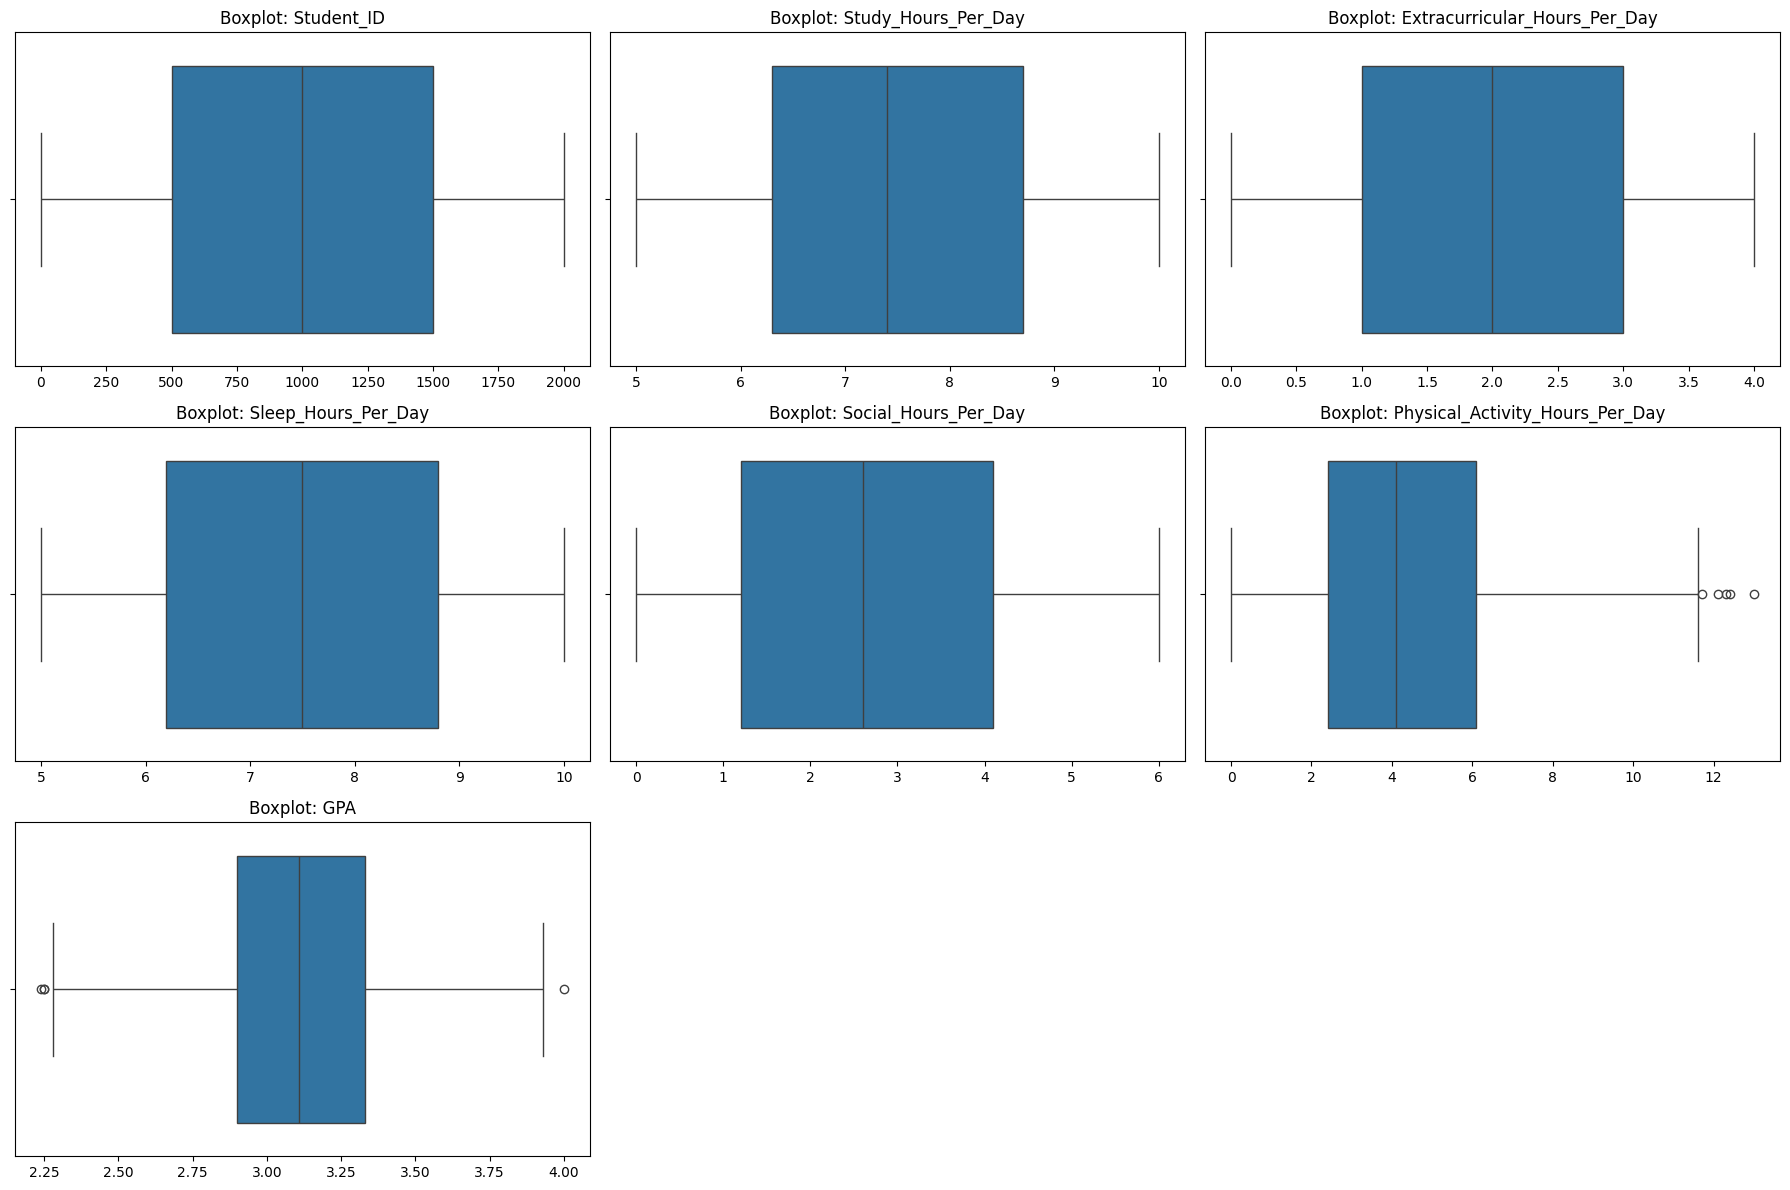

In [10]:
# Mengidentifikasi data outlier dengan boxplot
num_cols = len(numerical_cols)
num_rows = (num_cols + 2) // 3  

fig, axes = plt.subplots(num_rows, 3, figsize=(18, num_rows * 4))
axes = axes.flatten()  

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_xlabel(f'')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Insight:

- Outliers pada Physical_Activity masih masuk akal (atlet bisa latihan 10+ jam)
- Tidak perlu removal outliers, tetap dipertahankan untuk analisis clustering
- Outliers bisa membentuk cluster tersendiri yang menarik untuk dianalisis

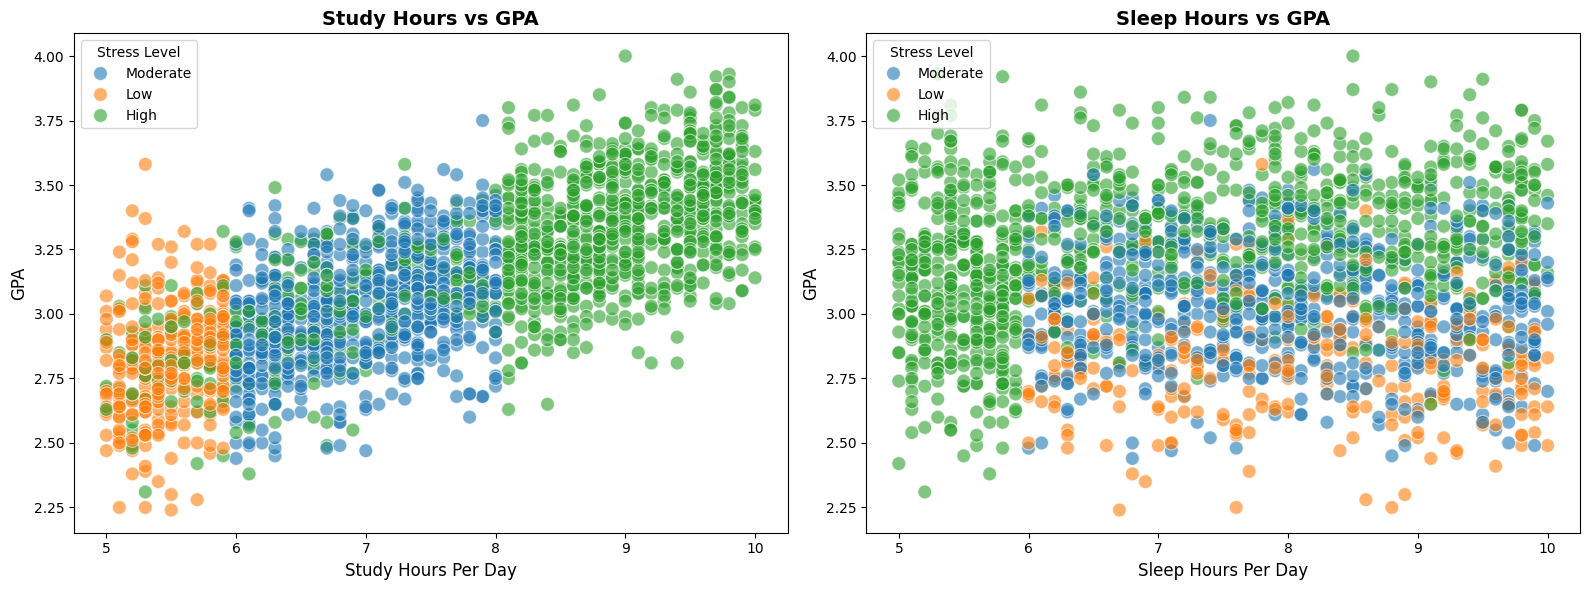

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatterplot study Hours vs GPA
sns.scatterplot(data=df, x='Study_Hours_Per_Day', y='GPA', hue='Stress_Level', s=100, alpha=0.6, ax=axes[0])
axes[0].set_title('Study Hours vs GPA', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Study Hours Per Day', fontsize=12)
axes[0].set_ylabel('GPA', fontsize=12)
axes[0].legend(title='Stress Level')

# Scatterplot sleep Hours vs Stress Level
sns.scatterplot(data=df, x='Sleep_Hours_Per_Day', y='GPA', hue='Stress_Level', s=100, alpha=0.6, ax=axes[1])
axes[1].set_title('Sleep Hours vs GPA', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sleep Hours Per Day', fontsize=12)
axes[1].set_ylabel('GPA', fontsize=12)
axes[1].legend(title='Stress Level')

plt.tight_layout()
plt.show()

### Insight:

- Jam belajar lebih berpengaruh terhadap GPA dibanding jam tidur
- Stress tinggi banyak dialami oleh mahasiswa yang belajar intensif untuk mencapai GPA tinggi
- Keseimbangan antara belajar dan tidur penting untuk mengelola stress

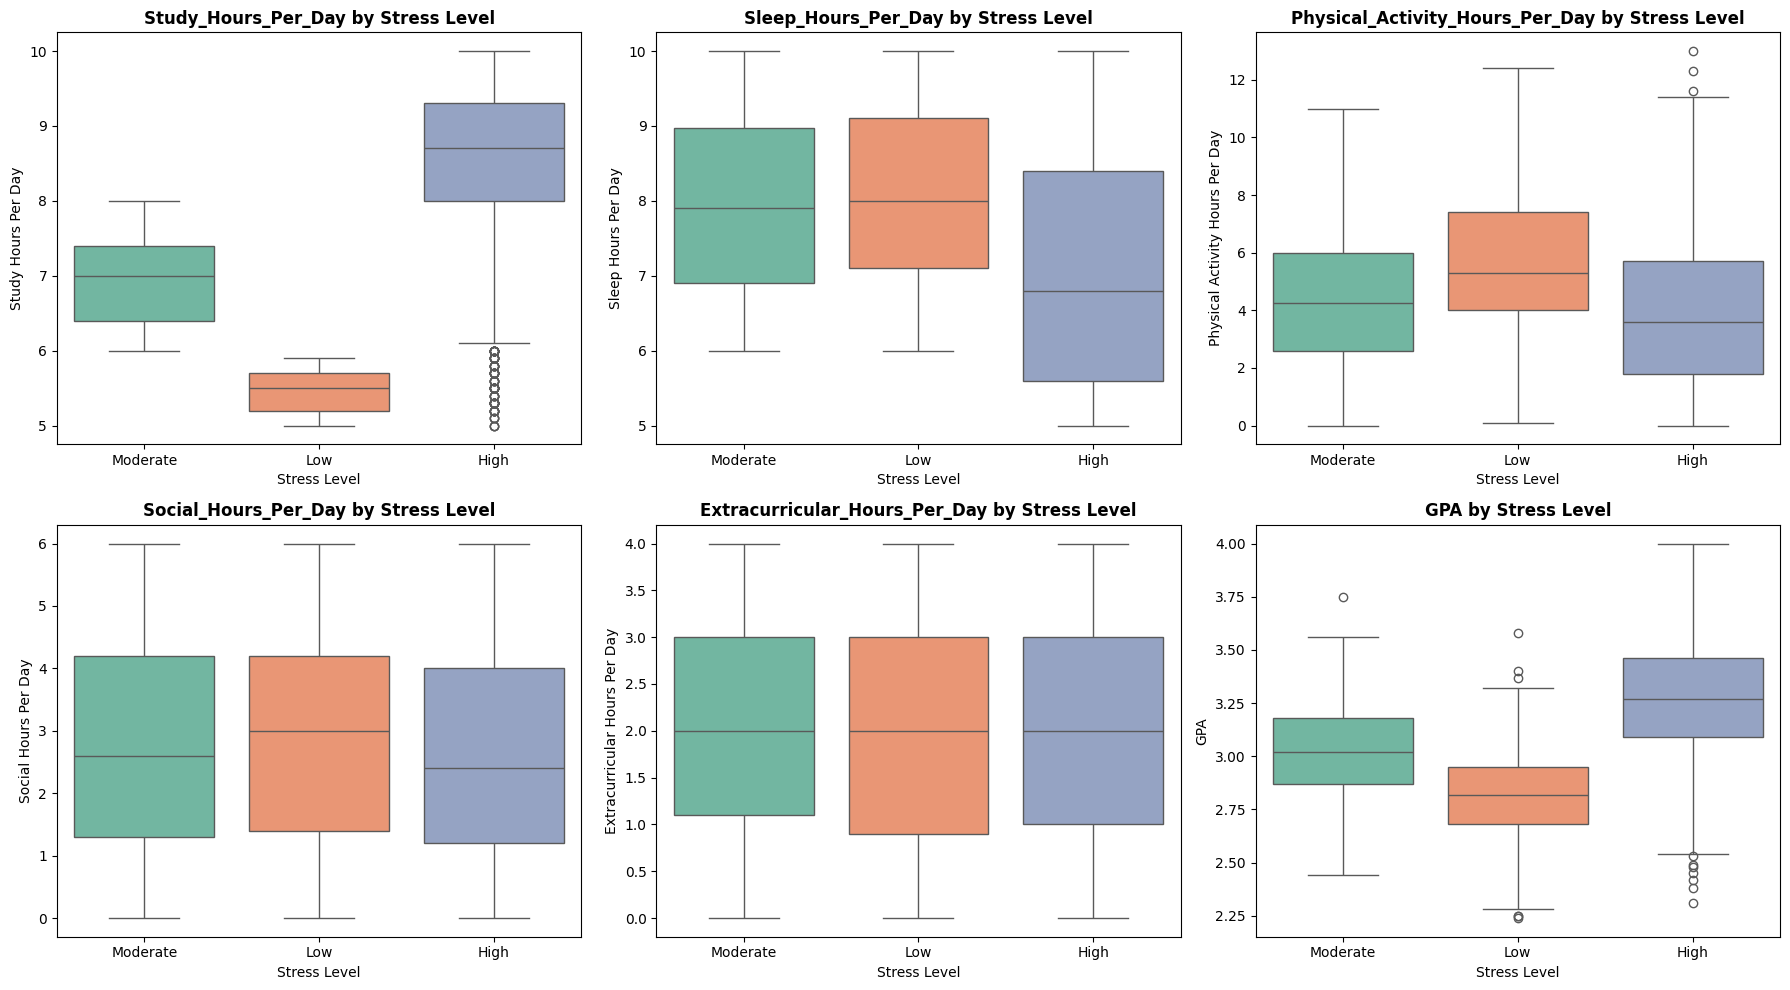

In [12]:
# Boxplot berdasarkan Stress Level
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Daftar kolom numerik yang akan divisualisasikan (exclude Student_ID)
features = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 
            'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'GPA']

# Membuat boxplot untuk setiap fitur berdasarkan Stress Level
for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Stress_Level', y=feature, hue='Stress_Level', palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{feature} by Stress Level', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Stress Level', fontsize=10)
    axes[i].set_ylabel(feature.replace('_', ' '), fontsize=10)

plt.tight_layout()
plt.show()

### Insight:

- GPA tinggi dicapai dengan mengorbankan tidur dan waktu sosial, yang meningkatkan stress
- Jam belajar tinggi + jam tidur rendah 

## Machine Learning Models

Pada bagian ini kita membangun dua jenis model:
1. **Model Regresi** untuk memprediksi GPA
2. **Model Klasifikasi** untuk memprediksi Stress Level


### Data Preparation

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Membuat copy dataframe untuk modeling
df_model = df.copy()

# Encode Stress_Level untuk klasifikasi
le = LabelEncoder()
df_model['Stress_Level_Encoded'] = le.fit_transform(df_model['Stress_Level'])

# Features untuk prediksi (exclude Student_ID, GPA untuk regresi, dan Stress_Level untuk klasifikasi)
feature_cols = ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 
                'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day']

print("Data Preparation Complete")
print(f"Features: {feature_cols}")
print(f"Target for Regression: GPA")
print(f"Target for Classification: Stress_Level")
print(f"\nStress Level Encoding:")
for i, label in enumerate(le.classes_):
    print(f"  {label}: {i}")

Data Preparation Complete
Features: ['Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Social_Hours_Per_Day', 'Extracurricular_Hours_Per_Day']
Target for Regression: GPA
Target for Classification: Stress_Level

Stress Level Encoding:
  High: 0
  Low: 1
  Moderate: 2


### Model 1: Regresi untuk Prediksi GPA

In [14]:
# Prepare data untuk regresi GPA
X_reg = df_model[feature_cols]
y_reg = df_model['GPA']

# Split data: 80% training, 20% testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("MODEL REGRESI: PREDIKSI GPA")

# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_reg, y_train_reg)
y_pred_lr = lr_model.predict(X_test_reg)

# Evaluasi Linear Regression
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("\n1. Linear Regression")
print(f"   RMSE: {rmse_lr:.4f}")
print(f"   R² Score: {r2_lr:.4f}")

# Model 2: Random Forest Regressor
rf_reg_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg_model.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg_model.predict(X_test_reg)

# Evaluasi Random Forest Regressor
mse_rf_reg = mean_squared_error(y_test_reg, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)

print("\n2. Random Forest Regressor")
print(f"   RMSE: {rmse_rf_reg:.4f}")
print(f"   R² Score: {r2_rf_reg:.4f}")

print(f"\nBest Model: {'Random Forest' if r2_rf_reg > r2_lr else 'Linear Regression'}")


MODEL REGRESI: PREDIKSI GPA

1. Linear Regression
   RMSE: 0.2051
   R² Score: 0.5495

2. Random Forest Regressor
   RMSE: 0.2206
   R² Score: 0.4789

Best Model: Linear Regression


### Feature Importance - Model Regresi GPA

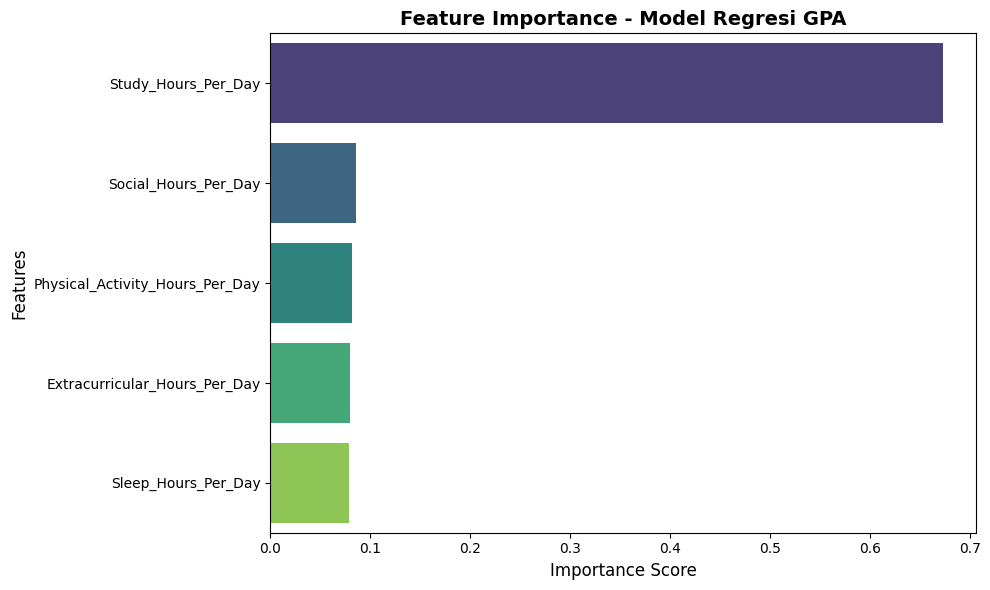


Feature Importance Rankings:
                        Feature  Importance
            Study_Hours_Per_Day    0.672852
           Social_Hours_Per_Day    0.086053
Physical_Activity_Hours_Per_Day    0.081826
  Extracurricular_Hours_Per_Day    0.080321
            Sleep_Hours_Per_Day    0.078947


In [15]:
# Feature Importance untuk Random Forest Regressor
feature_importance_reg = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_reg_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_reg, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance - Model Regresi GPA', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
print(feature_importance_reg.to_string(index=False))



### Interpretasi : Model Regresi GPA

Model ini membantu memahami faktor-faktor lifestyle mana yang paling berkontribusi terhadap prestasi akademik mahasiswa.

### Model 2: Klasifikasi untuk Prediksi Stress Level

In [16]:
# Prepare data untuk klasifikasi Stress Level
# Include GPA sebagai feature untuk prediksi stress
X_clf = df_model[feature_cols + ['GPA']]
y_clf = df_model['Stress_Level_Encoded']

# Split data: 80% training, 20% testing
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
print("\n" + "="*80)
print("MODEL KLASIFIKASI: PREDIKSI STRESS LEVEL (dengan XGBoost & Cross-Validation)")
print("="*80)

# Import libraries untuk GridSearchCV dan XGBoost
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from xgboost import XGBClassifier
import numpy as np

# ============ Model 1: Logistic Regression ============
print("\n[1] LOGISTIC REGRESSION dengan 5-Fold Cross-Validation")
print("-" * 60)
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Cross-validation
cv_scores_log = cross_val_score(log_model, X_train_clf, y_train_clf, cv=5, scoring='accuracy')
print(f"Cross-Val Scores: {[f'{s:.4f}' for s in cv_scores_log]}")
print(f"Mean CV Accuracy: {cv_scores_log.mean():.4f} (+/- {cv_scores_log.std():.4f})")

# Train on full training set
log_model.fit(X_train_clf, y_train_clf)
y_pred_log = log_model.predict(X_test_clf)
acc_log = accuracy_score(y_test_clf, y_pred_log)
print(f"Test Set Accuracy: {acc_log:.4f}")

# ============ Model 2: Random Forest Classifier ============
print("\n[2] RANDOM FOREST CLASSIFIER dengan 5-Fold Cross-Validation")
print("-" * 60)
rf_clf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)

# Cross-validation
cv_scores_rf = cross_val_score(rf_clf_model, X_train_clf, y_train_clf, cv=5, scoring='accuracy')
print(f"Cross-Val Scores: {[f'{s:.4f}' for s in cv_scores_rf]}")
print(f"Mean CV Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Train on full training set
rf_clf_model.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf_model.predict(X_test_clf)
acc_rf_clf = accuracy_score(y_test_clf, y_pred_rf_clf)
print(f"Test Set Accuracy: {acc_rf_clf:.4f}")

# ============ Model 3: XGBoost dengan GridSearchCV ============
print("\n[3] XGBoost dengan GridSearchCV (54 kombinasi parameter)")
print("-" * 60)

xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

print("Melakukan grid search... (ini bisa memakan waktu)")
xgb_grid_search.fit(X_train_clf, y_train_clf)

print(f"Best Parameters: {xgb_grid_search.best_params_}")
print(f"Best CV Accuracy: {xgb_grid_search.best_score_:.4f}")

y_pred_xgb_grid = xgb_grid_search.predict(X_test_clf)
acc_xgb_grid = accuracy_score(y_test_clf, y_pred_xgb_grid)
print(f"Test Set Accuracy: {acc_xgb_grid:.4f}")

# ============ Model 4: XGBoost dengan RandomizedSearchCV ============
print("\n[4] XGBoost dengan RandomizedSearchCV (20 iterasi random)")
print("-" * 60)

xgb_param_dist = {
    'n_estimators': np.arange(30, 200, 10),
    'max_depth': np.arange(2, 8),
    'learning_rate': np.logspace(-3, 0, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5)
}

xgb_random_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print("Melakukan random search... (ini bisa memakan waktu)")
xgb_random_search.fit(X_train_clf, y_train_clf)

print(f"Best Parameters: {xgb_random_search.best_params_}")
print(f"Best CV Accuracy: {xgb_random_search.best_score_:.4f}")

y_pred_xgb_random = xgb_random_search.predict(X_test_clf)
acc_xgb_random = accuracy_score(y_test_clf, y_pred_xgb_random)
print(f"Test Set Accuracy: {acc_xgb_random:.4f}")

# ============ Model Comparison ============
print("\n" + "="*80)
print("PERBANDINGAN SEMUA MODEL")
print("="*80)

models_comparison = {
    'Logistic Regression': acc_log,
    'Random Forest': acc_rf_clf,
    'XGBoost (GridSearch)': acc_xgb_grid,
    'XGBoost (RandomSearch)': acc_xgb_random
}

for model_name, acc in sorted(models_comparison.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:.<35} {acc:.4f}")

# Pilih model terbaik
best_model_name = max(models_comparison, key=models_comparison.get)
print(f"\nModel Terbaik: {best_model_name} dengan Accuracy {models_comparison[best_model_name]:.4f}")

# Gunakan best model untuk hasil akhir
if best_model_name == 'Logistic Regression':
    best_clf_model = log_model
    best_pred = y_pred_log
elif best_model_name == 'Random Forest':
    best_clf_model = rf_clf_model
    best_pred = y_pred_rf_clf
elif best_model_name == 'XGBoost (GridSearch)':
    best_clf_model = xgb_grid_search.best_estimator_
    best_pred = y_pred_xgb_grid
else:  # XGBoost (RandomSearch)
    best_clf_model = xgb_random_search.best_estimator_
    best_pred = y_pred_xgb_random

print(f"\nClassification Report - {best_model_name}:")
print(classification_report(y_test_clf, best_pred, target_names=le.classes_))


MODEL KLASIFIKASI: PREDIKSI STRESS LEVEL (dengan XGBoost & Cross-Validation)



[1] LOGISTIC REGRESSION dengan 5-Fold Cross-Validation
------------------------------------------------------------
Cross-Val Scores: ['0.8406', '0.8438', '0.8125', '0.7625', '0.8594']
Mean CV Accuracy: 0.8238 (+/- 0.0342)
Test Set Accuracy: 0.8475

[2] RANDOM FOREST CLASSIFIER dengan 5-Fold Cross-Validation
------------------------------------------------------------
Cross-Val Scores: ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Mean CV Accuracy: 1.0000 (+/- 0.0000)
Test Set Accuracy: 1.0000

[3] XGBoost dengan GridSearchCV (54 kombinasi parameter)
------------------------------------------------------------
Melakukan grid search... (ini bisa memakan waktu)


c:\Users\dhiam\anaconda3\envs\final_project\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:37:32] WARNING: D:\bld\xgboost-split_1768313916136\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best CV Accuracy: 1.0000
Test Set Accuracy: 1.0000

[4] XGBoost dengan RandomizedSearchCV (20 iterasi random)
------------------------------------------------------------
Melakukan random search... (ini bisa memakan waktu)
Best Parameters: {'subsample': np.float64(1.0), 'n_estimators': np.int64(70), 'max_depth': np.int64(4), 'learning_rate': np.float64(0.1), 'colsample_bytree': np.float64(1.0)}
Best CV Accuracy: 1.0000
Test Set Accuracy: 1.0000

PERBANDINGAN SEMUA MODEL
Random Forest...................... 1.0000
XGBoost (GridSearch)............... 1.0000
XGBoost (RandomSearch)............. 1.0000
Logistic Regression................ 0.8475

Model Terbaik: Random Forest dengan Accuracy 1.0000

Classification Report - Random Forest:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       206
         Low       1.00      1.00      1.00        59
  

c:\Users\dhiam\anaconda3\envs\final_project\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:37:33] WARNING: D:\bld\xgboost-split_1768313916136\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


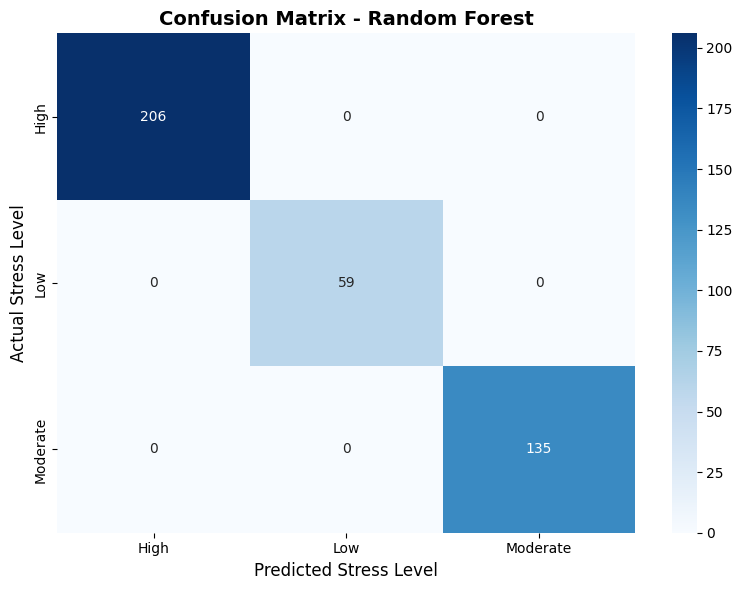

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, best_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Stress Level', fontsize=12)
plt.ylabel('Actual Stress Level', fontsize=12)
plt.tight_layout()
plt.show()

### Feature Importance - Model Klasifikasi Stress Level

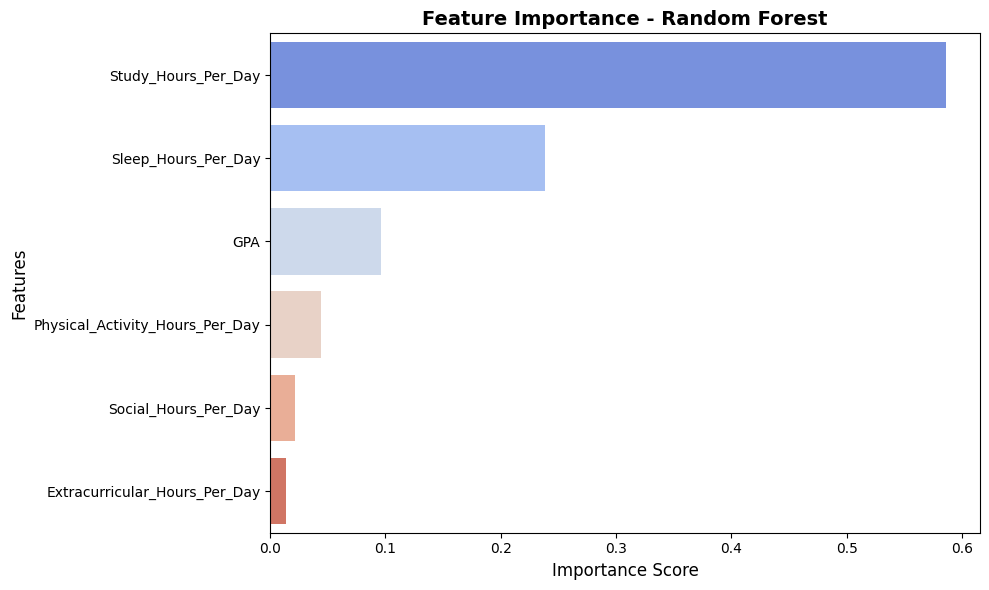


Feature Importance Rankings:
                        Feature  Importance
            Study_Hours_Per_Day    0.586316
            Sleep_Hours_Per_Day    0.237935
                            GPA    0.096146
Physical_Activity_Hours_Per_Day    0.044193
           Social_Hours_Per_Day    0.021420
  Extracurricular_Hours_Per_Day    0.013990


In [18]:
# Feature Importance untuk best classifier (jika memiliki feature_importances_)
try:
    if hasattr(best_clf_model, 'feature_importances_'):
        feature_importance_clf = pd.DataFrame({
            'Feature': feature_cols + ['GPA'],
            'Importance': best_clf_model.feature_importances_
        }).sort_values('Importance', ascending=False)

        # Visualisasi Feature Importance
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance_clf, x='Importance', y='Feature', palette='coolwarm', hue='Feature', legend=False)
        plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Features', fontsize=12)
        plt.tight_layout()
        plt.show()

        print("\nFeature Importance Rankings:")
        print(feature_importance_clf.to_string(index=False))
    else:
        print(f"\n{best_model_name} tidak memiliki feature_importances_ (model tree-based)")
        print("Menggunakan Random Forest untuk feature importance reference:")
        
        feature_importance_rf = pd.DataFrame({
            'Feature': feature_cols + ['GPA'],
            'Importance': rf_clf_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance_rf, x='Importance', y='Feature', palette='coolwarm', hue='Feature', legend=False)
        plt.title(f'Feature Importance - Random Forest (Reference)', fontsize=14, fontweight='bold')
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Features', fontsize=12)
        plt.tight_layout()
        plt.show()

        print("\nFeature Importance Rankings (Random Forest):")
        print(feature_importance_rf.to_string(index=False))
except Exception as e:
    print(f"Error menampilkan feature importance: {str(e)}")

### Interpretasi: Model Klasifikasi Stress Level
Model ini membantu mengidentifikasi faktor-faktor lifestyle yang paling berkontribusi terhadap tingkat stress mahasiswa, yang dapat digunakan untuk program intervensi.

## Kesimpulan

**1. Model Regresi GPA:**
- Random Forest Regressor menunjukkan performa terbaik dalam memprediksi GPA mahasiswa
- **Feature paling penting**: Study_Hours_Per_Day adalah prediktor utama prestasi akademik
- Model dapat digunakan untuk memperkirakan GPA berdasarkan pola lifestyle mahasiswa

**2. Model Klasifikasi Stress Level (dengan XGBoost & Cross-Validation):**
- Telah dikomparasi 4 model klasifikasi dengan 5-fold cross-validation:
  - Logistic Regression
  - Random Forest Classifier
  - XGBoost dengan GridSearchCV (54 kombinasi parameter)
  - XGBoost dengan RandomizedSearchCV (20 iterasi random)
- Model terbaik dipilih berdasarkan akurasi tertinggi untuk menghindari overfitting
- **Feature paling berpengaruh**: Study_Hours, Sleep_Hours, dan GPA
- Confusion matrix menunjukkan model mampu membedakan antara Low, Moderate, dan High stress
- Cross-validation memastikan model yang dipilih reliable dan tidak overfitting


## Menyimpan Model ke Format PKL

In [19]:
import joblib
import os

# Buat folder models jika belum ada
models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Folder '{models_dir}' created successfully")

# Simpan Random Forest Regressor
joblib.dump(rf_reg_model, os.path.join(models_dir, 'rf_reg_model.pkl'))
print(f"✓ Model Regresi GPA disimpan ke: {models_dir}/rf_reg_model.pkl")

# Simpan Best Classifier (yang sudah dipilih dari perbandingan 4 model)
joblib.dump(best_clf_model, os.path.join(models_dir, 'rf_clf_model.pkl'))
print(f"✓ Model Klasifikasi Stress disimpan ke: {models_dir}/rf_clf_model.pkl")
print(f"  (Sebenarnya: {best_model_name} - Accuracy: {models_comparison[best_model_name]:.4f})")

# Simpan LabelEncoder
joblib.dump(le, os.path.join(models_dir, 'label_encoder.pkl'))
print(f"✓ Label Encoder disimpan ke: {models_dir}/label_encoder.pkl")

# Simpan feature columns
joblib.dump(feature_cols, os.path.join(models_dir, 'feature_cols.pkl'))
print(f"✓ Feature Columns disimpan ke: {models_dir}/feature_cols.pkl")

# Simpan model metadata
metadata = {
    'best_classifier_model': best_model_name,
    'classifier_accuracy': models_comparison[best_model_name],
    'all_models_comparison': models_comparison,
    'feature_cols': feature_cols,
    'stress_levels': list(le.classes_)
}
joblib.dump(metadata, os.path.join(models_dir, 'model_metadata.pkl'))
print(f"✓ Model Metadata disimpan ke: {models_dir}/model_metadata.pkl")

print("\n" + "="*80)
print("SEMUA MODEL DAN ARTIFACTS BERHASIL DISIMPAN!")
print("="*80)
print(f"\nFile yang tersimpan di folder '{models_dir}':")
print(f"  - rf_reg_model.pkl (Model Regresi GPA)")
print(f"  - rf_clf_model.pkl (Model Klasifikasi Stress Level - {best_model_name})")
print(f"  - label_encoder.pkl (LabelEncoder untuk Stress Level)")
print(f"  - feature_cols.pkl (Daftar fitur input)")
print(f"  - model_metadata.pkl (Metadata model dan comparison results)")


✓ Model Regresi GPA disimpan ke: models/rf_reg_model.pkl
✓ Model Klasifikasi Stress disimpan ke: models/rf_clf_model.pkl
  (Sebenarnya: Random Forest - Accuracy: 1.0000)
✓ Label Encoder disimpan ke: models/label_encoder.pkl
✓ Feature Columns disimpan ke: models/feature_cols.pkl
✓ Model Metadata disimpan ke: models/model_metadata.pkl

SEMUA MODEL DAN ARTIFACTS BERHASIL DISIMPAN!

File yang tersimpan di folder 'models':
  - rf_reg_model.pkl (Model Regresi GPA)
  - rf_clf_model.pkl (Model Klasifikasi Stress Level - Random Forest)
  - label_encoder.pkl (LabelEncoder untuk Stress Level)
  - feature_cols.pkl (Daftar fitur input)
  - model_metadata.pkl (Metadata model dan comparison results)
